In [ ]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import randint
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold

In [ ]:
df = pd.read_csv("Customer-Churn-Records.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [4]:
df.drop(columns=["RowNumber", "CustomerId", "Surname", 'Complain'], inplace=True)

cat_cols = ["Geography", "Gender", "Card Type"]
for c in cat_cols:
    df[c] = df[c].astype("category")


In [5]:
X = df.drop("Exited", axis = 1)  # target feature 
y = df["Exited"]
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Satisfaction Score,Card Type,Point Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,5,GOLD,425


In [6]:
X_train, X_val, y_train, y_val = train_test_split(X, y, train_size = 0.8, random_state = 42, stratify = y)

In [7]:
base = LGBMClassifier(
    n_estimators = 2000,
    objective = "binary",
    random_state = 42,
    n_jobs = -1
)

param_grid = {
    "n_estimators" : randint(400, 1200),
    "max_depth": randint(-1, 16),
    "num_leaves": randint(16, 256)
}

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search = RandomizedSearchCV(
    estimator = base,
    param_distributions = param_grid,
    n_iter = 30,
    scoring = "roc_auc",
    cv = cv,
    random_state = 42,
    n_jobs = -1
)

In [ ]:
search.fit(X_train, y_train)
best_model = search.best_estimator_
print("Best AUC:", search.best_score_)
print("Best params:", search.best_params_)

In [13]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[18,25,35,45,55,65,100],
    labels=["18-25","25-35","35-45","45-55","55-65","65+"]
)

df["BalanceGroup"] = pd.cut(
    df["Balance"],
    bins=[-1, 0, 50000, 150000, df["Balance"].max()],
    labels=["Zero","Low","Mid","High"]
)

In [14]:
# 单指标分析 single metric Analysis 
features = [
    "AgeGroup",
    "Gender",
    "Geography",
    "NumOfProducts",
    "IsActiveMember",
    "BalanceGroup"
]

for f in features:
    print("\n",f)
    print(df.groupby(f)["Exited"].mean())


 AgeGroup
AgeGroup
18-25    0.074703
25-35    0.084980
35-45    0.196467
45-55    0.505721
55-65    0.483209
65+      0.132576
Name: Exited, dtype: float64

 Gender
Gender
Female    0.250715
Male      0.164743
Name: Exited, dtype: float64

 Geography
Geography
France     0.161747
Germany    0.324432
Spain      0.166734
Name: Exited, dtype: float64

 NumOfProducts
NumOfProducts
1    0.277144
2    0.076035
3    0.827068
4    1.000000
Name: Exited, dtype: float64

 IsActiveMember
IsActiveMember
0    0.268715
1    0.142691
Name: Exited, dtype: float64

 BalanceGroup
BalanceGroup
Zero    0.138236
Low     0.346667
Mid     0.241244
High    0.231166
Name: Exited, dtype: float64


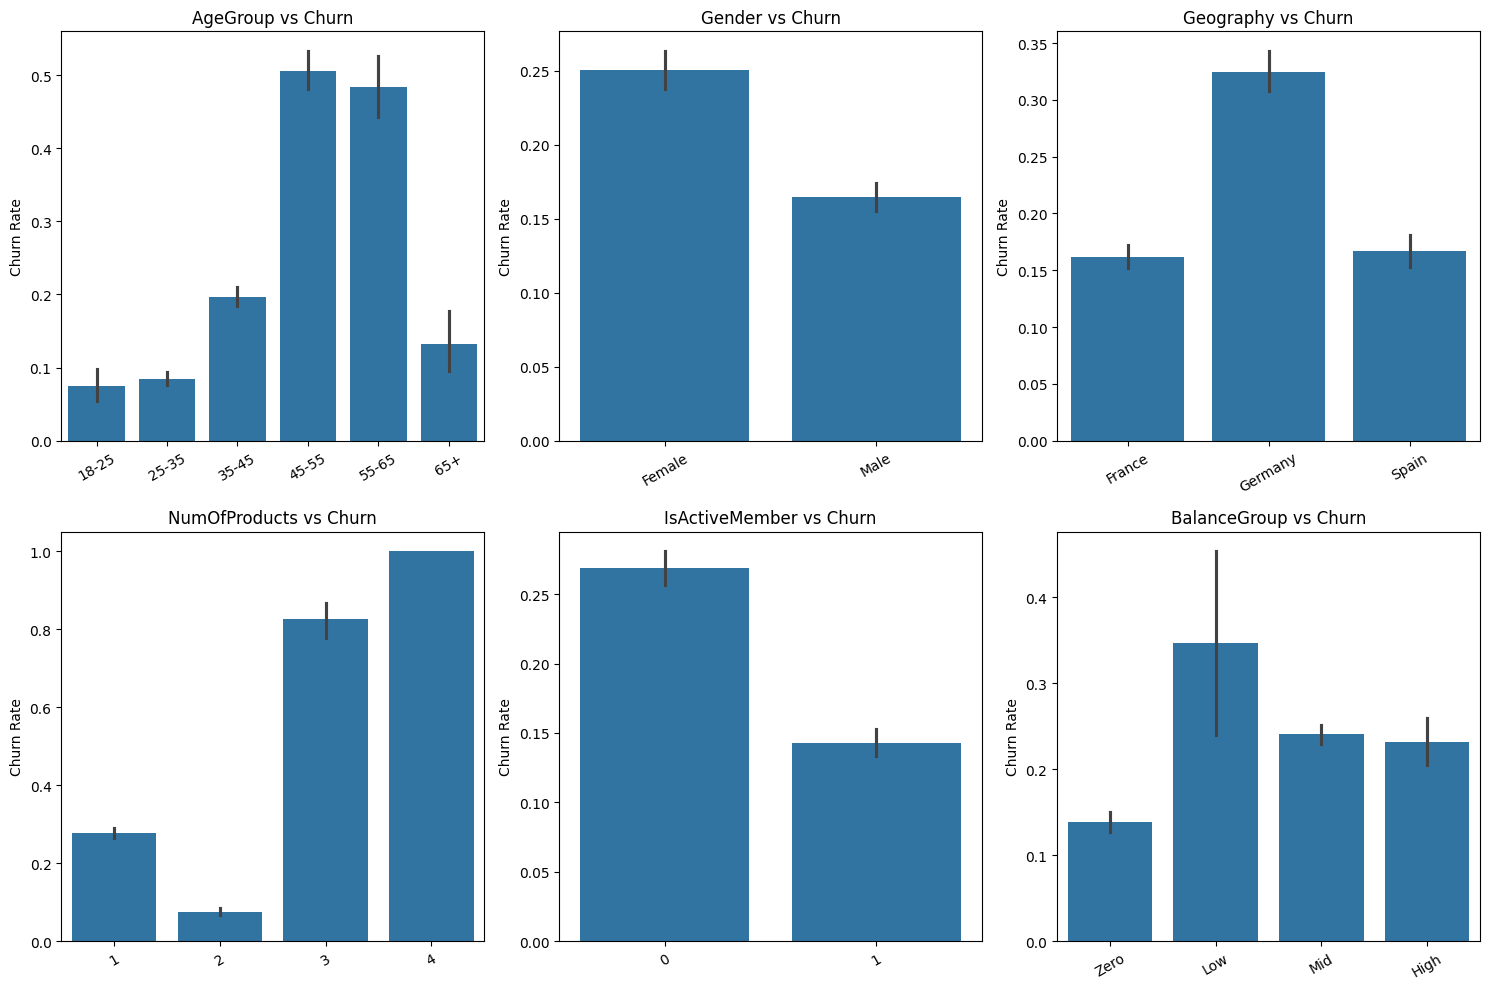

In [15]:
fig, axes = plt.subplots(2,3, figsize=(15,10))

axes = axes.flatten()

for i, col in enumerate(features):

    sns.barplot(
        x=col,
        y="Exited",
        data=df,
        ax=axes[i]
    )

    axes[i].set_title(f"{col} vs Churn")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Churn Rate")

    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

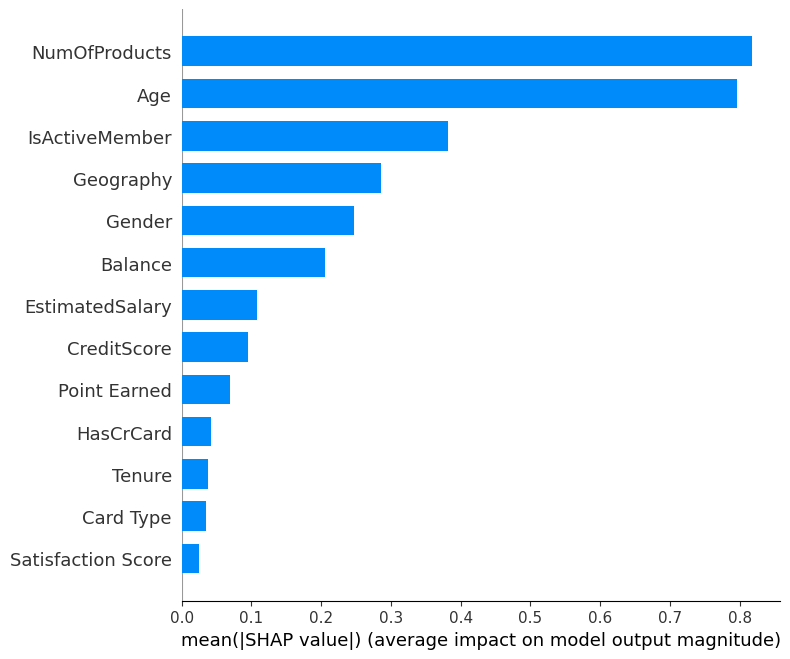

In [16]:
explainer = shap.TreeExplainer(best_model)
X_sample = X_val.sample(1000, random_state=42) if len(X_val) > 1000 else X_val

sv = explainer(X_sample)

vals = sv.values
if vals.ndim == 3:
    vals = vals[:, :, 1]  # exited = 1

shap.summary_plot(vals, X_sample, plot_type="bar", max_display=20)

In [17]:
# 用户分层 User Segmentation
# 先根据 客户存款 + 活跃度 + 风险 规则分层 Segment customers based on customer balance, engagement and risk
df["churn_prob"] = best_model.predict_proba(X)[:,1]
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Card Type,Point Earned,AgeGroup,BalanceGroup,churn_prob
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,2,DIAMOND,464,35-45,Zero,0.305826
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,3,DIAMOND,456,35-45,Mid,0.230173
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,3,DIAMOND,377,35-45,High,0.945348
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,5,GOLD,350,35-45,Zero,0.046526
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,5,GOLD,425,35-45,Mid,0.097311


In [19]:
def segment_user(row):
    balance_q75 = df["Balance"].quantile(0.75)

    if row["Balance"] > balance_q75 and row["churn_prob"] < 0.3:  # high balance, low risk of exiting -> VIP benefits
        return "VIP_Stable"

    elif row["Balance"] > balance_q75 and row["churn_prob"] > 0.7:  # high balance, high risk of exiting -> managers follow-up
        return "VIP_Risk"

    elif row["churn_prob"] > 0.7:  # low or medium balance, high risk of exiting -> promotion activity
        return "Churn_Risk"

    elif row["IsActiveMember"] == 0:  # low activity -> promotion activity
        return "Inactive"

    else:
        return "Normal"  # normal customers -> product recommendation

# 重点人群: Churn_Risk，VIP_Risk，Inactive (Priority groups: Churn_Risk，VIP_Risk，Inactive)
df["UserSegment"] = df.apply(segment_user, axis=1)

In [20]:
df["UserSegment"].value_counts(normalize=True)
# 普通稳定客户占多数，其次是不活跃用户 The mojority are normal,loyal customers

UserSegment
Normal        0.3974
Inactive      0.3364
VIP_Stable    0.1881
Churn_Risk    0.0553
VIP_Risk      0.0228
Name: proportion, dtype: float64

In [21]:
segment_profile = df.groupby("UserSegment")[[
    "Age",
    "Balance",
    "NumOfProducts",
    "IsActiveMember",
    "Exited"
]].mean()

print(segment_profile)

                   Age        Balance  NumOfProducts  IsActiveMember    Exited
UserSegment                                                                   
Churn_Risk   50.701627   69665.674014       1.763110        0.153707  0.922242
Inactive     36.504162   56720.927916       1.549941        0.000000  0.178359
Normal       39.971817   55869.653110       1.534977        1.000000  0.128334
VIP_Risk     49.100877  149276.191316       1.881579        0.184211  0.925439
VIP_Stable   36.330144  148571.823796       1.373737        0.558214  0.110048


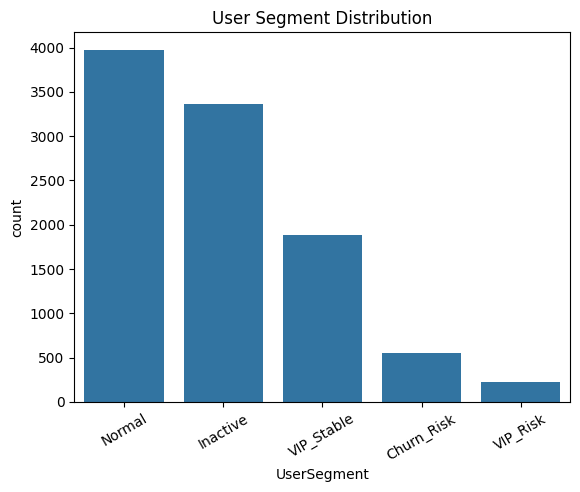

In [22]:
sns.countplot(
    x="UserSegment",
    data=df,
    order=df["UserSegment"].value_counts().index
)

plt.title("User Segment Distribution")
plt.xticks(rotation=30)
plt.show()

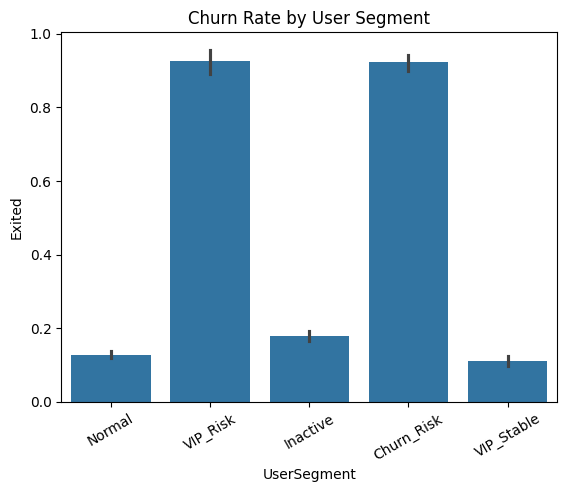

In [23]:
sns.barplot(
    x="UserSegment",
    y="Exited",
    data=df
)

plt.title("Churn Rate by User Segment")
plt.xticks(rotation=30)
plt.show()

In [27]:
# 再利用K-means同层人群聚类 K-means clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [40]:
def cluster_within_segment(df, segment_name, cluster_features, k_range=range(2,6), best_k=None):
    pd.set_option("display.max_columns", None)   # 显示所有列
    pd.set_option("display.width", 200)          # 增加一行显示宽度
    pd.set_option("display.max_colwidth", None)  # 列内容不截断

    seg_df = df[df["UserSegment"] == segment_name].copy()
    print(f"\nSegment: {segment_name}, sample size: {len(seg_df)}")

    X_cluster = seg_df[cluster_features].copy()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_cluster)

    inertia_list = []
    silhouette_list = []

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_scaled)
        inertia_list.append(kmeans.inertia_)
        silhouette_list.append(silhouette_score(X_scaled, labels))

    # 输出每个k的指标
    for k, inertia, sil in zip(k_range, inertia_list, silhouette_list):
        print(f"k={k}, inertia={inertia:.2f}, silhouette={sil:.4f}")

    plt.figure(figsize=(6,4))
    plt.plot(list(k_range), inertia_list, marker='o')
    plt.xlabel("k")
    plt.ylabel("Inertia")
    plt.title(f"Elbow - {segment_name}")
    plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(list(k_range), silhouette_list, marker='o')
    plt.xlabel("k")
    plt.ylabel("Silhouette Score")
    plt.title(f"Silhouette - {segment_name}")
    plt.show()

    if best_k is None:
        best_k = list(k_range)[np.argmax(silhouette_list)]

    print("Selected k:", best_k)

    kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    seg_df["SubCluster"] = kmeans.fit_predict(X_scaled)

    profile_cols = cluster_features + ["Exited", "churn_prob"]
    cluster_profile = seg_df.groupby("SubCluster")[profile_cols].mean().round(2)
    cluster_count = seg_df["SubCluster"].value_counts().sort_index()

    print("\nCluster Count:")
    print(cluster_count)

    print("\nCluster Profile:")
    print(cluster_profile)

    return seg_df, cluster_profile


Segment: VIP_Risk, sample size: 228
k=2, inertia=1250.64, silhouette=0.2382
k=3, inertia=1103.81, silhouette=0.1663
k=4, inertia=973.75, silhouette=0.1786


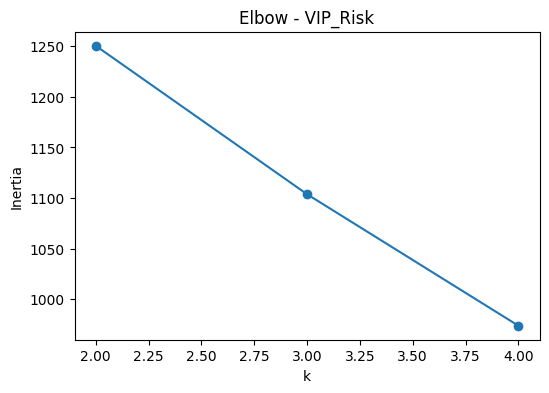

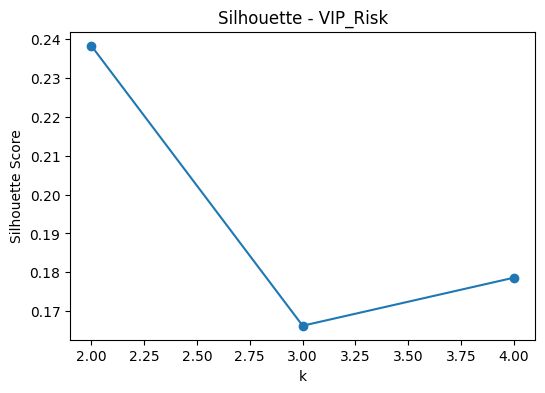

Selected k: 2

Cluster Count:
SubCluster
0     79
1    149
Name: count, dtype: int64

Cluster Profile:
              Age    Balance  NumOfProducts  IsActiveMember  EstimatedSalary  Tenure  CreditScore  Exited  churn_prob
SubCluster                                                                                                           
0           41.10  150448.12           3.22            0.48        102222.52    5.39       667.38    0.97        0.95
1           53.34  148654.84           1.17            0.03        110544.14    4.87       641.05    0.90        0.85

Segment: Churn_Risk, sample size: 553
k=2, inertia=3132.80, silhouette=0.2289
k=3, inertia=2733.40, silhouette=0.1852
k=4, inertia=2413.35, silhouette=0.1958


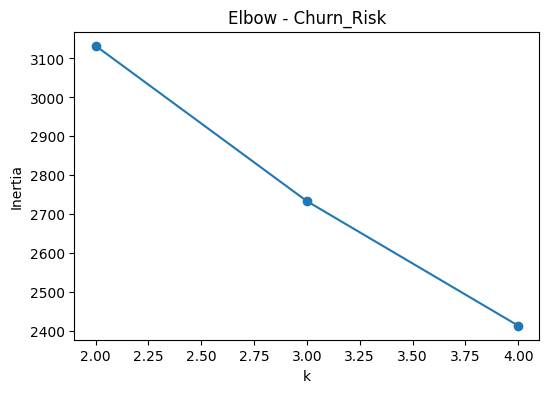

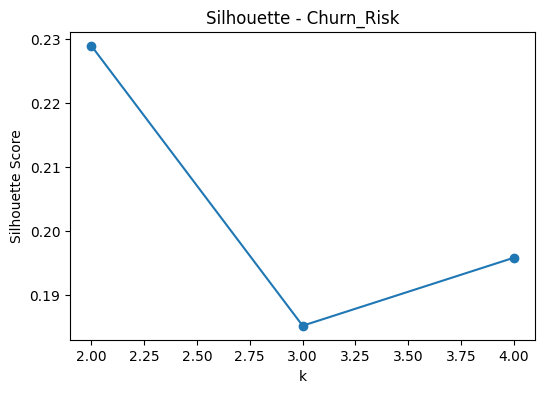

Selected k: 2

Cluster Count:
SubCluster
0    168
1    385
Name: count, dtype: int64

Cluster Profile:
              Age   Balance  NumOfProducts  IsActiveMember  EstimatedSalary  Tenure  CreditScore  Exited  churn_prob
SubCluster                                                                                                          
0           45.31  73263.98           3.10             0.5        111911.75    4.83       624.36    0.96        0.91
1           53.05  68095.51           1.18             0.0        100491.43    4.89       644.20    0.91        0.84


In [42]:
cluster_features = [
    "Age",
    "Balance",
    "NumOfProducts",
    "IsActiveMember",
    "EstimatedSalary",
    "Tenure",
    "CreditScore"
]


vip_risk_df, vip_risk_profile = cluster_within_segment(
    df=df,
    segment_name="VIP_Risk",
    cluster_features=cluster_features,
    k_range=range(2,5),
    best_k=None
)

churn_risk_df, churn_risk_profile = cluster_within_segment(
    df=df,
    segment_name="Churn_Risk",
    cluster_features=cluster_features,
    k_range=range(2,5),
    best_k=None
)


## 关键结论

综合单指标分析、规则分层与同层聚类分析，可得到以下结论：

### 1. 单指标分析：活跃度、年龄、产品数与流失率关系最明显
从年龄、性别、地区、产品数、活跃状态和存款分组的单指标分析来看，客户流失并非随机发生，而是与若干核心特征显著相关：

- **活跃状态**与流失率差异最明显，不活跃客户流失风险显著更高；
- **年龄**越大，整体流失率越高；
- **产品数**较少的客户整体更容易流失；
- **存款水平**也会影响流失表现，高余额客户虽然价值高，但并不一定稳定。

这说明：**客户活跃度、年龄、产品绑定程度和资产水平，是流失分析中最值得重点关注的基础维度。**

### 2. 规则分层：高风险人群主要集中在 `VIP_Risk` 与 `Churn_Risk`
基于“**客户价值 + 活跃度 + 流失风险**”，将客户划分为 `Normal`、`Inactive`、`Churn_Risk`、`VIP_Stable` 和 `VIP_Risk` 五类客群。

其中最值得重点关注的两类是：

- **`VIP_Risk`**：**228 人**，平均余额约 **149,276**，流失率 **92.54%**
- **`Churn_Risk`**：**533 人**，流失率 **92.22%**

同时：
- `Inactive` 客户活跃度为 **0**，流失率约 **17.84%**
- `Churn_Risk` 平均活跃度仅 **0.154**
- `VIP_Risk` 平均活跃度仅 **0.184**

这说明：

- **活跃度下降是最显著的流失信号**
- **高价值客户并不一定稳定**
- `VIP_Risk` 与 `Churn_Risk` 虽然人数占比不高，但都是最值得优先干预的核心风险人群

### 3. 同层聚类：`VIP_Risk` 内部还可进一步拆分为两类客户
在规则分层基础上，进一步对 `VIP_Risk` 客群进行 K-means 同层聚类，最终选择 **k=2**，识别出两类典型高价值高风险客户：

#### SubCluster 0（79 人）：深度绑定流失型 VIP
- 年龄：**41.10**
- 余额：**150,448**
- 产品数：**3.22**
- 活跃度：**0.48**
- Tenure：**5.39**
- 信用分：**667.38**
- 流失率：**0.97**
- 平均预测流失概率：**0.95**

这类客户特点是：**产品绑定较深、关系历史较长、仍有一定活跃度，但流失风险极高**。  
说明这部分客户的流失原因，更可能来自**服务体验、权益匹配或竞品替代**，而不只是产品覆盖不足。

#### SubCluster 1（149 人）：高资产浅绑定型 VIP
- 年龄：**53.34**
- 余额：**148,655**
- 产品数：**1.17**
- 活跃度：**0.03**
- Tenure：**4.87**
- 信用分：**641.05**
- 流失率：**0.90**
- 平均预测流失概率：**0.85**

这类客户特点是：**资产规模高，但产品持有少、活跃度极低、关系较浅**。  
说明这类客户属于典型的**高价值但脆弱型客户**，更容易因缺乏关系深度而流失。

### 4. 同层聚类：`Churn_Risk` 内部也存在差异化子群
接着对 `Churn_Risk` 同样进行 K-means 同层聚类，结果显示 **k=2** 更合适。

#### `VIP_Risk` 客群
在 `VIP_Risk` 中，共识别出两类典型高价值高风险客户：

**SubCluster 0（79 人）**
- 年龄：**41.10**
- 余额：**150,448**
- 产品数：**3.22**
- 活跃度：**0.48**
- Tenure：**5.39**
- 信用分：**667.38**
- 流失率：**0.97**
- 平均预测流失概率：**0.95**

这类客户表现为：**产品绑定较深、关系历史较长、仍有一定活跃度，但流失风险依然极高**。

**SubCluster 1（149 人）**
- 年龄：**53.34**
- 余额：**148,655**
- 产品数：**1.17**
- 活跃度：**0.03**
- Tenure：**4.87**
- 信用分：**641.05**
- 流失率：**0.90**
- 平均预测流失概率：**0.85**

这类客户表现为：**年龄偏大、产品持有少、活跃度极低**，属于典型的高价值但关系较脆弱的客户。

#### `Churn_Risk` 客群
在 `Churn_Risk` 中，同样识别出两类典型高流失风险客户：

**SubCluster 0（168 人）**
- 年龄：**45.31**
- 余额：**73,264**
- 产品数：**3.10**
- 活跃度：**0.50**
- Tenure：**4.83**
- 信用分：**624.36**
- 流失率：**0.96**
- 平均预测流失概率：**0.91**

这类客户表现为：**虽然产品持有较多、仍有一定活跃度，但依然处于极高流失状态**。

**SubCluster 1（385 人）**
- 年龄：**53.05**
- 余额：**68,096**
- 产品数：**1.18**
- 活跃度：**0.00**
- Tenure：**4.89**
- 信用分：**644.20**
- 流失率：**0.91**
- 平均预测流失概率：**0.84**

这类客户表现为：**年龄偏大、产品数较少、几乎完全不活跃**，是更典型的脆弱型高风险客户。

整体来看，`VIP_Risk` 与 `Churn_Risk` 内部都呈现出相似的分化特征：一类客户虽然仍保有一定活跃度和较多产品，但流失风险依然很高；另一类则更明显地表现为**年龄偏大、产品数少、活跃度极低**。这说明：**高风险客户并非单一画像，其内部仍存在不同的流失机制，需要进一步细分管理。**

### 5. 结论落地：应围绕不同风险机制制定差异化策略
整体来看，本项目得到两个核心业务结论：

- **流失风险的核心前置信号是活跃度下降**
- **同属高风险客户，内部流失机制并不相同**

因此在运营上应采用差异化策略：

- 对 **`Churn_Risk`**：优先做**促活召回**
- 对 **`VIP_Risk` - 深度绑定流失型**：优先做**服务修复、专属维护**
- 对 **`VIP_Risk` - 高资产浅绑定型**：优先做**产品渗透、关系加深**
- 对 **`Inactive`**：通过权益激励、定向触达进行唤醒

这说明：**规则分层解决“先找出谁最值得管”，同层聚类进一步解决“同一类客户该怎么更细地管”。**

## Key Findings

Based on single-feature analysis, rule-based segmentation, and within-segment clustering, the following conclusions can be drawn.

---

### 1. Single-Factor Analysis: Activity, Age, and Product Holdings Show the Strongest Relationship with Churn

From the single-variable analysis across **age, gender, geography, number of products, activity status, and account balance**, customer churn does not occur randomly. Instead, it is strongly associated with several key characteristics:

- **Activity status** shows the most significant difference in churn rates; inactive customers have a much higher risk of churn.
- **Older customers** tend to have a higher overall churn rate.
- Customers with **fewer products** are generally more likely to churn.
- **Account balance** also affects churn behavior. High-balance customers are valuable, but they are not necessarily stable.

These findings suggest that **customer activity level, age, product engagement, and asset level** are the most critical dimensions to consider when analyzing churn risk.

---

### 2. Rule-Based Segmentation: High-Risk Customers Concentrate in `VIP_Risk` and `Churn_Risk`

Using a rule-based segmentation framework combining **customer value, activity level, and churn risk**, customers were divided into five groups:

- `Normal`
- `Inactive`
- `Churn_Risk`
- `VIP_Stable`
- `VIP_Risk`

Among these groups, two segments require the most attention:

- **`VIP_Risk`**  
  - **228 customers**  
  - Average balance: **149,276**  
  - Churn rate: **92.54%**

- **`Churn_Risk`**  
  - **533 customers**  
  - Churn rate: **92.22%**

Additional observations:

- `Inactive` customers have **zero activity**, with a churn rate of about **17.84%**.
- `Churn_Risk` customers have an average activity level of only **0.154**.
- `VIP_Risk` customers have an average activity level of only **0.184**.

These findings indicate that:

- **Declining activity is the strongest signal of churn risk**
- **High-value customers are not necessarily stable**
- Although `VIP_Risk` and `Churn_Risk` represent a relatively small proportion of the total customer base, they are the **most critical groups for targeted intervention**

---

### 3. Within-Segment Clustering: `VIP_Risk` Customers Can Be Further Divided into Two Subgroups

Based on the rule-based segmentation, **K-means clustering** was applied within the `VIP_Risk` segment. The optimal number of clusters was **k = 2**, revealing two distinct types of high-value, high-risk customers.

#### SubCluster 0 (79 customers): Deeply Engaged but Churning VIPs

- Age: **41.10**
- Balance: **150,448**
- Number of products: **3.22**
- Activity level: **0.48**
- Tenure: **5.39**
- Credit score: **667.38**
- Churn rate: **0.97**
- Average predicted churn probability: **0.95**

These customers have **relatively deep product engagement, longer relationship tenure, and moderate activity**, yet their churn risk remains extremely high.

This suggests that their churn may be driven less by product coverage and more by **service experience, value perception, or competitive alternatives**.

#### SubCluster 1 (149 customers): High-Asset but Weakly Engaged VIPs

- Age: **53.34**
- Balance: **148,655**
- Number of products: **1.17**
- Activity level: **0.03**
- Tenure: **4.87**
- Credit score: **641.05**
- Churn rate: **0.90**
- Average predicted churn probability: **0.85**

These customers hold **substantial assets but have very limited product engagement and extremely low activity**.

This indicates a typical **high-value yet fragile customer segment**, where weak relationship depth increases the likelihood of churn.

---

### 4. Within-Segment Clustering: `Churn_Risk` Also Contains Distinct Subgroups

Applying K-means clustering to the `Churn_Risk` segment also suggests **k = 2** as the optimal solution.

#### SubCluster 0 (168 customers)

- Age: **45.31**
- Balance: **73,264**
- Number of products: **3.10**
- Activity level: **0.50**
- Tenure: **4.83**
- Credit score: **624.36**
- Churn rate: **0.96**
- Average predicted churn probability: **0.91**

These customers still maintain **multiple products and moderate activity**, yet they remain at extremely high risk of churn.

#### SubCluster 1 (385 customers)

- Age: **53.05**
- Balance: **68,096**
- Number of products: **1.18**
- Activity level: **0.00**
- Tenure: **4.89**
- Credit score: **644.20**
- Churn rate: **0.91**
- Average predicted churn probability: **0.84**

These customers are **older, hold fewer products, and are almost completely inactive**, representing a more typical fragile high-risk group.

Overall, both `VIP_Risk` and `Churn_Risk` segments exhibit a similar internal pattern:

- One subgroup maintains **moderate activity and product holdings but still shows high churn risk**
- The other subgroup is characterized by **older age, fewer products, and extremely low activity**

This indicates that **high-risk customers do not share a single profile**. Instead, different churn mechanisms exist within the same risk segment, requiring more granular management strategies.

---

### 5. Business Implications: Different Risk Mechanisms Require Different Strategies

Two key business insights emerge from this analysis:

- **Declining customer activity is the most important early signal of churn risk**
- **Customers within the same high-risk segment may leave for different reasons**

Therefore, differentiated operational strategies are necessary:

- For **`Churn_Risk` customers**: prioritize **reactivation and engagement campaigns**
- For **`VIP_Risk` – deeply engaged but churning customers**: prioritize **service recovery and personalized relationship management**
- For **`VIP_Risk` – high-asset but weakly engaged customers**: focus on **product penetration and relationship strengthening**
- For **`Inactive` customers**: use **incentives and targeted outreach** to stimulate activity

In essence:

- **Rule-based segmentation answers the question: “Which customers should we focus on first?”**
- **Within-segment clustering answers the question: “How should we manage them differently?”**